In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import time
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  当前设备: {device}")

train_transform = transforms.Compose([
    transforms.RandomCrop(32,padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914,0.4822,0.4465],
        std=[0.2470,0.2435,0.2616]
    ),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
       mean=[0.4914, 0.4822, 0.4465],
       std =[0.2470, 0.2435, 0.2616] 
    ),
])

train_dataset = datasets.CIFAR10(
    root='./data',train=True,download=False,transform=train_transform
)
val_dataset = datasets.CIFAR10(
    root='./data',train=False,download=False,transform=val_transform
)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"📊 训练样本数: {len(train_dataset)}")
print(f"📊 验证样本数: {len(val_dataset)}")
print(f"📦 Batch Size:  {BATCH_SIZE}")

class MediumCNN(nn.Module):
    def __init__(self,num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
            
            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),

            nn.Conv2d(128,256,kernel_size=3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
            )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4,512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes),
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = MediumCNN(num_classes=10).to(device)
print(f'\n🧠 模型结构:\n{model}')
        
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"📐 总参数量: {total_params:,}")
print(f"📐 可训练参数量: {trainable_params:,}")
        
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = optim.lr_scheduler.StepLR(optimizer,step_size=10,gamma=0.1)

def train_one_epoch(model,loader,criterion,optimizer,device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0
    for batch_idx,(inputs,targets) in enumerate(loader):
        
        inputs,targets = inputs.to(device),targets.to(device)
        
        outputs = model(inputs)

        loss = criterion(outputs,targets)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _,predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch [{batch_idx+1}/{len(loader)}]  "
                  f"Loss: {loss.item():.4f}  "
                  f"Acc: {100.0 * correct / total:.2f}%")
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss,epoch_acc

@torch.no_grad()
def evaluate(model,loader,criterion,device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs,targets in loader:
        inputs,targets = inputs.to(device),targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs,targets)

        running_loss += loss.item() * inputs.size(0)
        _,predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss,epoch_acc


NUM_EPOCHS = 20
best_acc = 0.0
best_model_wts = None

print("\n" + "=" * 60)
print("🚀 开始训练")
print("=" * 60)

start_time = time.time()

for epoch in range(1,NUM_EPOCHS+1):
    epoch_start = time.time()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"\n📍 Epoch [{epoch}/{NUM_EPOCHS}]  (lr={current_lr:.6f})")
    print("-" * 50)

    train_loss,train_acc = train_one_epoch(
    model,train_loader,criterion,optimizer,device    
    )
    print(f"  🏋️  Train  →  Loss: {train_loss:.4f}  |  Acc: {train_acc:.2f}%")


    val_loss,val_acc = evaluate(
        model,val_loader,criterion,device
    )
    print(f"✅ Val    →  Loss: {val_loss:.4f}  |  Acc: {val_acc:.2f}%")

    scheduler.step()

    if val_acc > best_acc:
        bset_acc = val_acc
        bset_model_wts = copy.deepcopy(model.state_dict())

        torch.save(model.state_dict(),'best.pt')
        print(f"  💾 新最佳模型！已保存 → best.pth  (Acc: {best_acc:.2f}%)")

    epoch_time = time.time() - epoch_start
    print(f"  💾 新最佳模型！已保存 → best.pth  (Acc: {best_acc:.2f}%)")

total_time = time.time() - start_time

print("\n" + "=" * 60)
print(f"🏁 训练完成！ 总耗时: {total_time:.1f}s")
print(f"🏆 最佳验证准确率: {best_acc:.2f}%")
print("=" * 60)

model.load_state_dict(torch.load("best.pth", map_location=device))
print("\n📂 已加载最佳模型 best.pth")

test_loss,test_acc = evaluate(model,val_loader,criterion,device)
print(f"🎯 最终测试 → Loss: {test_loss:.4f}  |  Acc: {test_acc:.2f}%")




🖥️  当前设备: cuda


d:\pythonprojects\practice-github\torch_final\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


📊 训练样本数: 50000
📊 验证样本数: 10000
📦 Batch Size:  128

🧠 模型结构:
MediumCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-

C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_22224\2784900716.py:212: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best.pth", map_loca

🎯 最终测试 → Loss: 0.5122  |  Acc: 82.17%


In [2]:
"""
=============================================================
 PyTorch 完整训练与评估流水线
 目标：CIFAR-10 图像分类
 架构：3 层卷积 + 2 层全连接（中等 CNN）
=============================================================
"""

# ──────────────────────────────────────────────
# 0. 导入依赖
# ──────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time
import copy


# ──────────────────────────────────────────────
# 1. 设定设备（GPU / CPU）
# ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  当前设备: {device}")


# ──────────────────────────────────────────────
# 2. 数据加载与预处理
# ──────────────────────────────────────────────

# ---------- 训练集：数据增强 + 归一化 ----------
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),           # 随机裁剪（先填充4像素）
    transforms.RandomHorizontalFlip(),              # 50% 概率水平翻转
    transforms.ColorJitter(brightness=0.2,          # 颜色抖动
                           contrast=0.2,
                           saturation=0.2),
    transforms.ToTensor(),                          # 转为 Tensor, 值域 [0,1]
    transforms.Normalize(                           # 标准化（CIFAR-10 统计量）
        mean=[0.4914, 0.4822, 0.4465],
        std =[0.2470, 0.2435, 0.2616]
    ),
])

# ---------- 验证/测试集：仅归一化，不做增强 ----------
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std =[0.2470, 0.2435, 0.2616]
    ),
])

# ---------- 下载并加载数据集 ----------
train_dataset = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_transform
)
val_dataset = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=val_transform
)

# ---------- DataLoader ----------
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # 训练集打乱顺序
    num_workers=2,          # 多进程加载
    pin_memory=True,        # 加速 CPU→GPU 传输
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # 验证集不打乱
    num_workers=2,
    pin_memory=True,
)

print(f"📊 训练样本数: {len(train_dataset)}")
print(f"📊 验证样本数: {len(val_dataset)}")
print(f"📦 Batch Size:  {BATCH_SIZE}")


# ──────────────────────────────────────────────
# 3. 定义中等规模 CNN
# ──────────────────────────────────────────────

class MediumCNN(nn.Module):
    """
    网络结构：
        Conv Block 1: Conv3x3 → BN → ReLU → MaxPool
        Conv Block 2: Conv3x3 → BN → ReLU → MaxPool
        Conv Block 3: Conv3x3 → BN → ReLU → MaxPool
        FC Block 1:   Linear → ReLU → Dropout
        FC Block 2:   Linear (输出)
    """
    def __init__(self, num_classes=10):
        super().__init__()

        # ---------- 卷积层部分 ----------
        self.features = nn.Sequential(
            # Block 1: 3×32×32 → 64×16×16
            nn.Conv2d(3, 64, kernel_size=3, padding=1),    # 3→64, 32×32
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                             # 16×16

            # Block 2: 64×16×16 → 128×8×8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),   # 64→128, 16×16
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                             # 8×8

            # Block 3: 128×8×8 → 256×4×4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),  # 128→256, 8×8
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                             # 4×4
        )

        # ---------- 全连接层部分 ----------
        self.classifier = nn.Sequential(
            nn.Flatten(),                                   # 256×4×4 → 4096
            nn.Linear(256 * 4 * 4, 512),                    # FC1: 4096→512
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),                                # 防止过拟合
            nn.Linear(512, num_classes),                    # FC2: 512→10
        )

    def forward(self, x):
        """
        x shape: [B, 3, 32, 32]
        """
        x = self.features(x)     # [B, 256, 4, 4]
        x = self.classifier(x)   # [B, 10]
        return x


# ---------- 实例化模型并移到设备 ----------
model = MediumCNN(num_classes=10).to(device)
print(f"\n🧠 模型结构:\n{model}")

# 统计参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"📐 总参数量: {total_params:,}")
print(f"📐 可训练参数量: {trainable_params:,}")


# ──────────────────────────────────────────────
# 4. 损失函数 & 优化器
# ──────────────────────────────────────────────

criterion = nn.CrossEntropyLoss()           # 内置 Softmax，适合多分类
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,                                # 学习率
    weight_decay=1e-4,                      # L2 正则化
)

# 学习率调度器：每 10 个 epoch 衰减为原来的 0.1 倍
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)


# ──────────────────────────────────────────────
# 5. 训练函数
# ──────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    训练一个 epoch，返回平均 loss 和准确率
    """
    model.train()  # ⭐ 切换到训练模式（启用 Dropout / BN 的训练行为）

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(loader):
        # ---- 数据搬到设备 ----
        inputs, targets = inputs.to(device), targets.to(device)

        # ---- Forward（前向传播）----
        outputs = model(inputs)              # [B, 10]

        # ---- 计算 Loss ----
        loss = criterion(outputs, targets)

        # ---- Backward（反向传播）----
        optimizer.zero_grad()                # ① 清零梯度（防止累加）
        loss.backward()                      # ② 反向传播，计算梯度

        # ---- 参数更新 ----
        optimizer.step()                     # ③ 根据梯度更新权重

        # ---- 统计 ----
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)        # 取概率最大的类别
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)

        # 打印进度
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch [{batch_idx+1}/{len(loader)}]  "
                  f"Loss: {loss.item():.4f}  "
                  f"Acc: {100.0 * correct / total:.2f}%")

    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total
    return epoch_loss, epoch_acc


# ──────────────────────────────────────────────
# 6. 评估函数
# ──────────────────────────────────────────────

@torch.no_grad()                             # ⭐ 等价于 with torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    评估模型，返回平均 loss 和准确率
    """
    model.eval()  # ⭐ 切换到评估模式（关闭 Dropout，BN 使用全局统计量）

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # ---- Forward ----
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # ---- 统计（不需要 backward / step）----
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += targets.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total
    return epoch_loss, epoch_acc


# ──────────────────────────────────────────────
# 7. 主训练循环
# ──────────────────────────────────────────────

NUM_EPOCHS = 20
best_acc = 0.0           # 记录最佳验证准确率
best_model_wts = None    # 记录最佳模型权重

print("\n" + "=" * 60)
print("🚀 开始训练")
print("=" * 60)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"\n📍 Epoch [{epoch}/{NUM_EPOCHS}]  (lr={current_lr:.6f})")
    print("-" * 50)

    # ---------- 训练 ----------
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    print(f"  🏋️  Train  →  Loss: {train_loss:.4f}  |  Acc: {train_acc:.2f}%")

    # ---------- 验证 ----------
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )
    print(f"  ✅ Val    →  Loss: {val_loss:.4f}  |  Acc: {val_acc:.2f}%")

    # ---------- 更新学习率 ----------
    scheduler.step()

    # ---------- 保存最佳模型 ----------
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())  # 深拷贝权重
        # 💾 保存到磁盘
        torch.save(model.state_dict(), "best.pth")
        print(f"  💾 新最佳模型！已保存 → best.pth  (Acc: {best_acc:.2f}%)")

    epoch_time = time.time() - epoch_start
    print(f"  ⏱️  Epoch 耗时: {epoch_time:.1f}s")

total_time = time.time() - start_time

print("\n" + "=" * 60)
print(f"🏁 训练完成！ 总耗时: {total_time:.1f}s")
print(f"🏆 最佳验证准确率: {best_acc:.2f}%")
print("=" * 60)


# ──────────────────────────────────────────────
# 8. 加载最佳模型并最终测试
# ──────────────────────────────────────────────

# 加载保存的最佳权重
model.load_state_dict(torch.load("best.pth", map_location=device))
print("\n📂 已加载最佳模型 best.pth")

# 最终验证
test_loss, test_acc = evaluate(model, val_loader, criterion, device)
print(f"🎯 最终测试 → Loss: {test_loss:.4f}  |  Acc: {test_acc:.2f}%")


# ──────────────────────────────────────────────
# 9. 可视化训练过程（可选）
# ──────────────────────────────────────────────

# 如果你想记录每个 epoch 的指标用于绘图，可以用列表收集：
#
# history = {
#     "train_loss": [], "train_acc": [],
#     "val_loss":   [], "val_acc":   [],
# }
# 在每个 epoch 结束后：
# history["train_loss"].append(train_loss)
# history["train_acc"].append(train_acc)
# history["val_loss"].append(val_loss)
# history["val_acc"].append(val_acc)
#
# 然后用 matplotlib 绘制曲线：
#
# import matplotlib.pyplot as plt
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# ax1.plot(history["train_loss"], label="Train Loss")
# ax1.plot(history["val_loss"],   label="Val Loss")
# ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()
# ax2.plot(history["train_acc"], label="Train Acc")
# ax2.plot(history["val_acc"],   label="Val Acc")
# ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend()
# plt.tight_layout(); plt.savefig("training_curves.png")

🖥️  当前设备: cuda
Files already downloaded and verified
Files already downloaded and verified
📊 训练样本数: 50000
📊 验证样本数: 10000
📦 Batch Size:  128

🧠 模型结构:
MediumCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=

C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_22224\672307433.py:308: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best.pth", map_locat

🎯 最终测试 → Loss: 0.4906  |  Acc: 83.24%


使用设备: cuda
PyTorch 版本: 2.5.1+cu121
训练集样本数: 60000
测试集样本数: 10000

模型参数量: 124,778
ModifiedLeNet(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=800, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

开始训练 (共 20 个 epoch)
Epoch

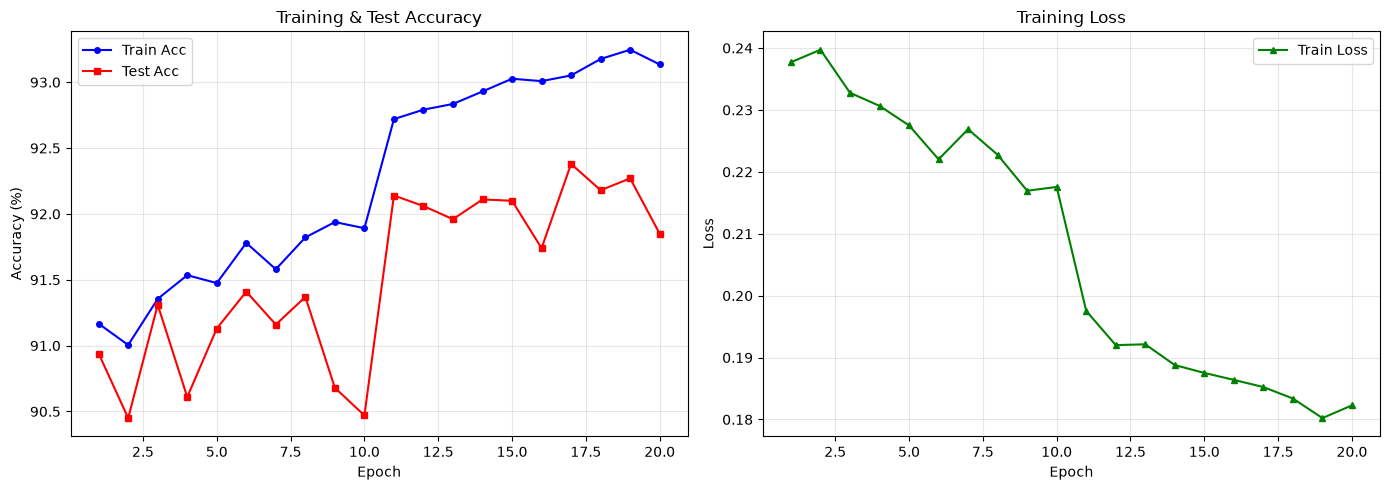

📊 训练曲线已保存到 training_curves.png


C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_22224\28859745.py:332: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


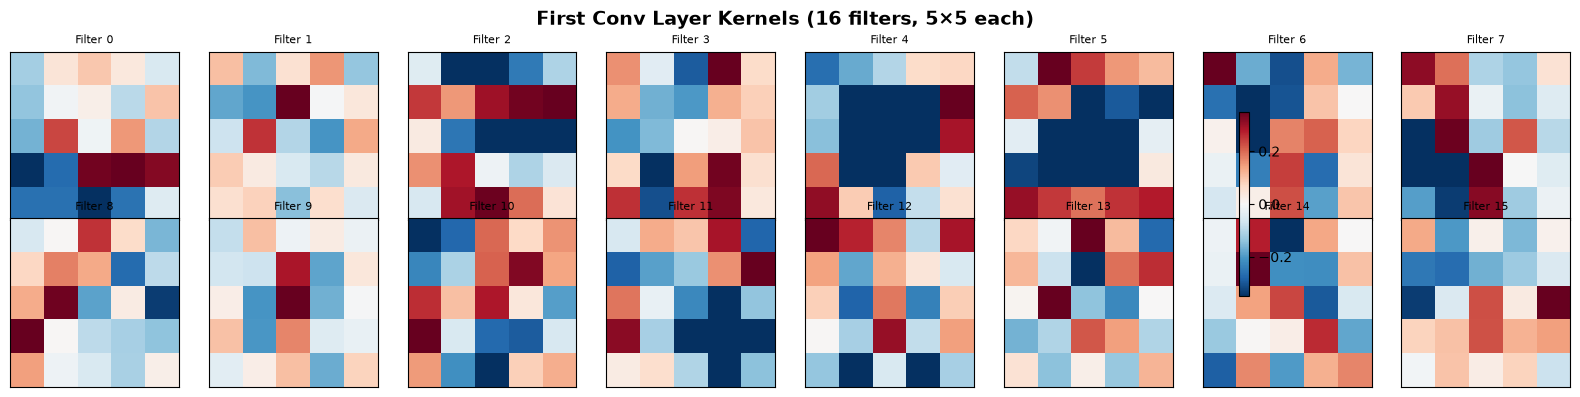

🔍 卷积核可视化已保存到 conv1_kernels.png


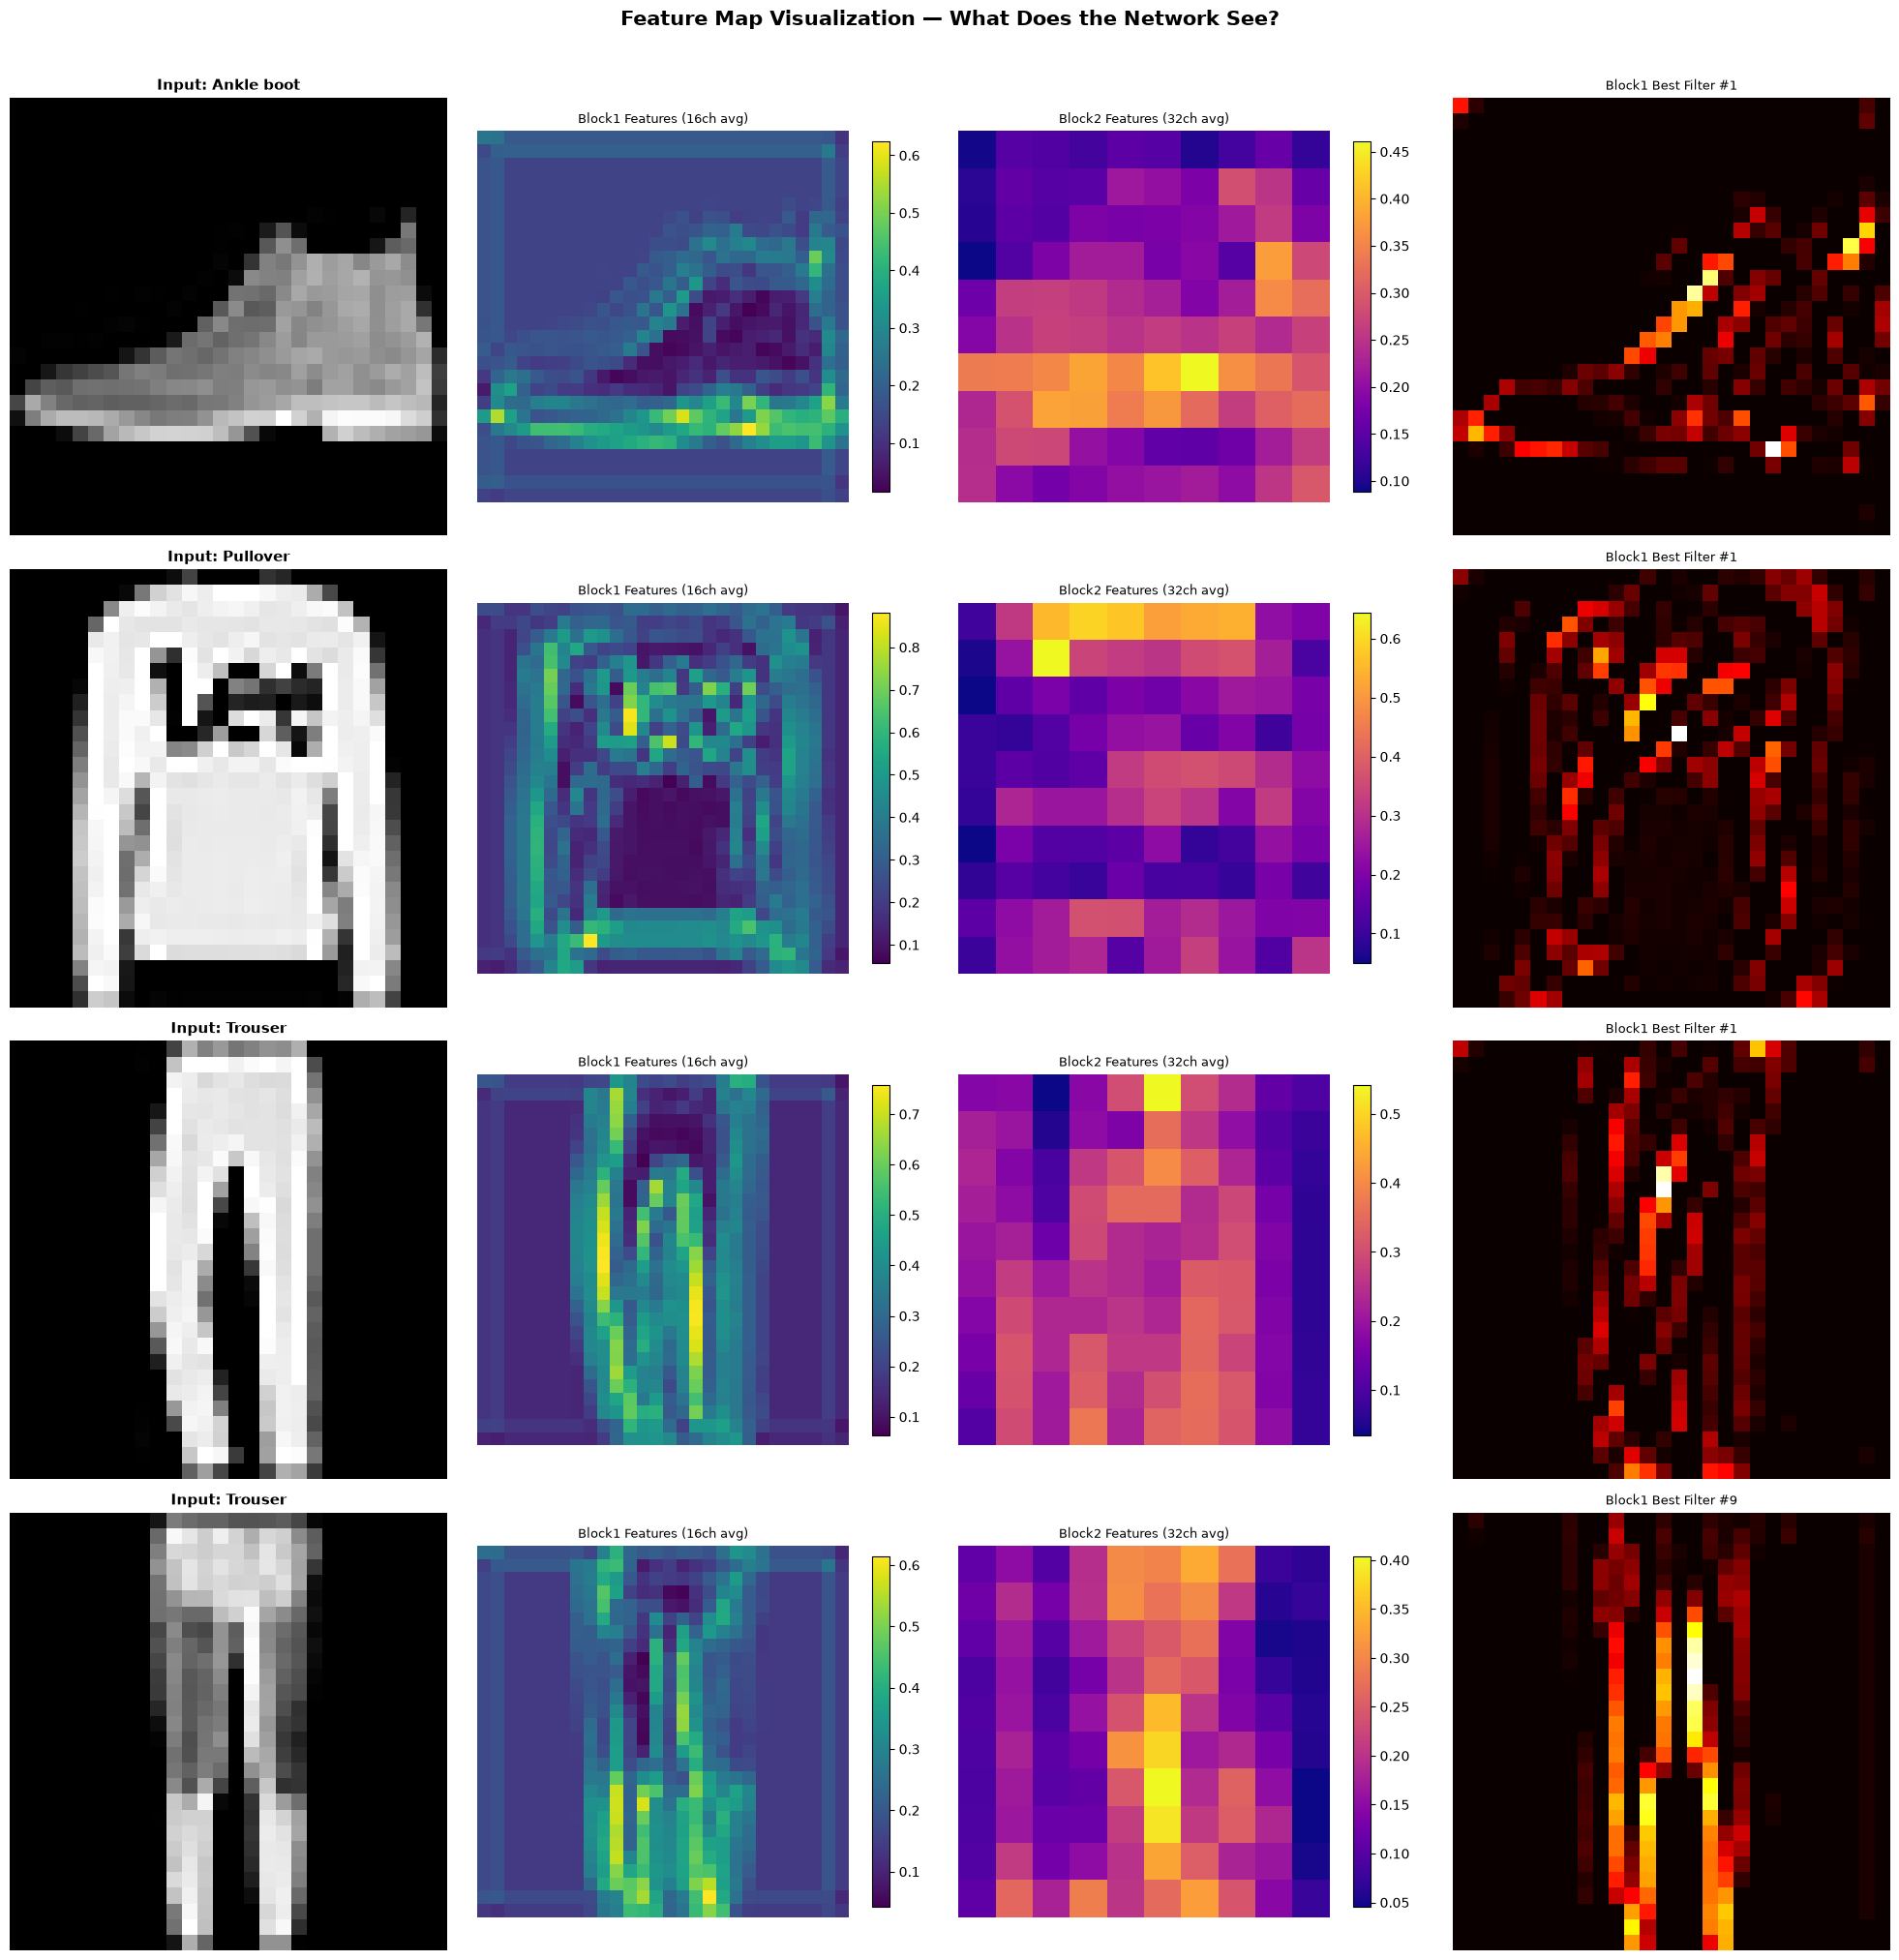

🗺️ 特征图可视化已保存到 feature_maps.png


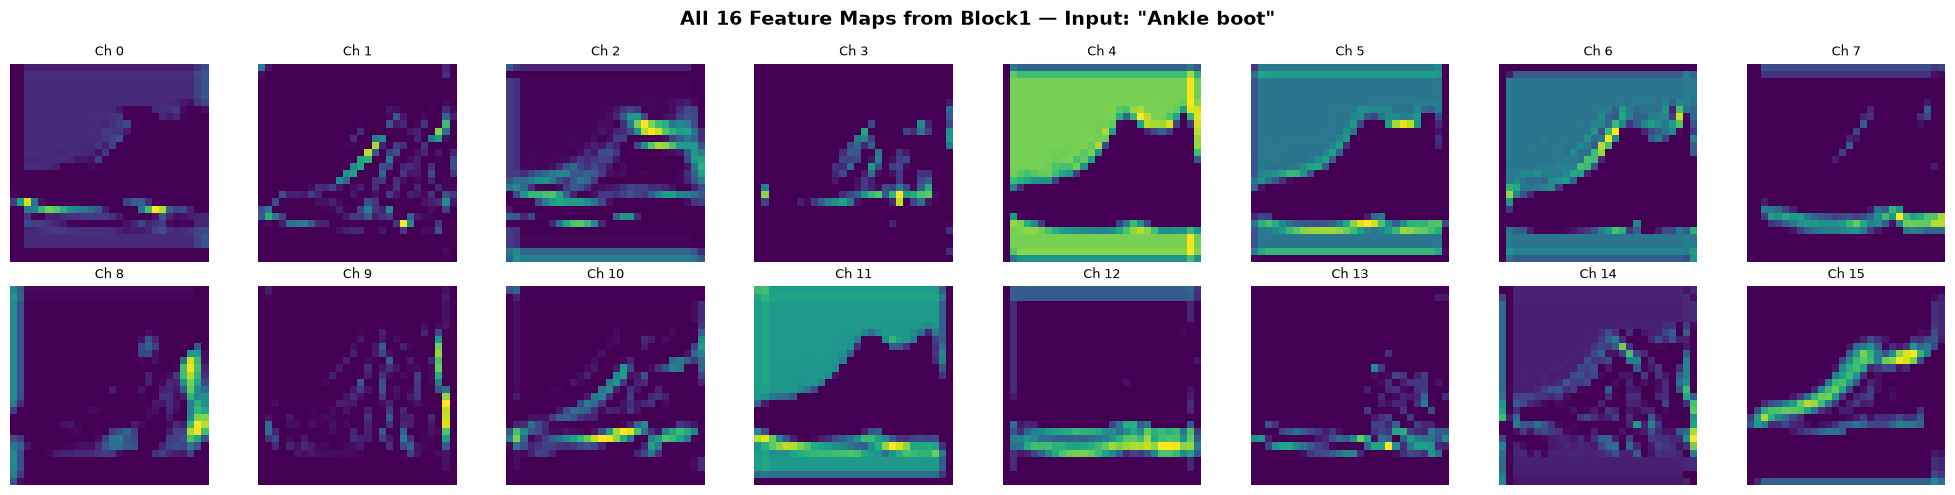

📡 逐通道特征图已保存到 all_channels.png


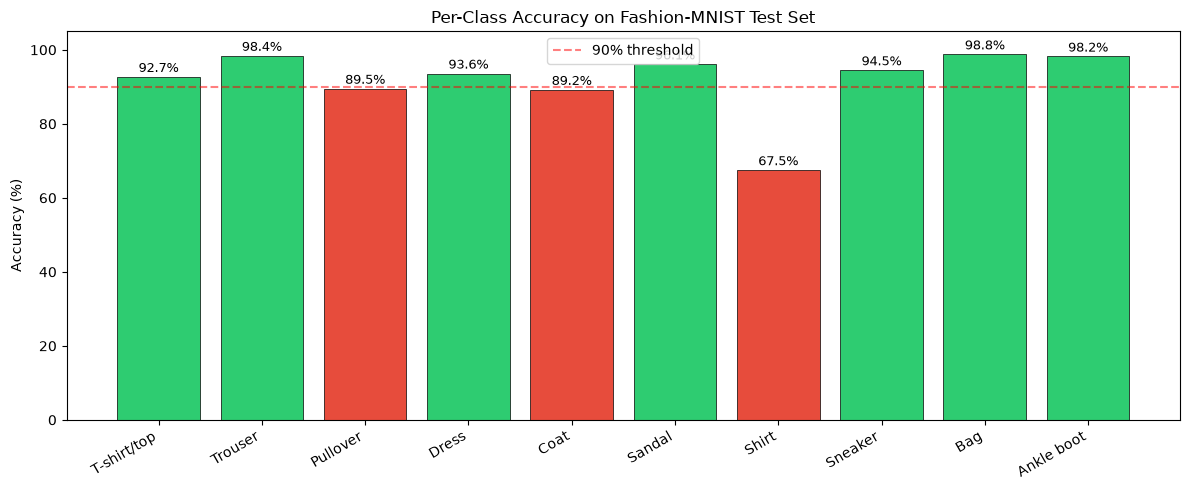

📊 逐类别准确率已保存到 per_class_accuracy.png


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

# ============================================================
# 0. 超参数 & 设备配置
# ============================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 128
NUM_EPOCHS = 20
LR = 1e-3
NUM_WORKERS = 2

print(f"使用设备: {DEVICE}")
print(f"PyTorch 版本: {torch.__version__}")

# ============================================================
# 1. 数据加载 (含数据增强)
# ============================================================

# 训练集 — 加入数据增强
train_transform = transforms.Compose([
    transforms.Pad(2),                    # 28→32, 为随机裁剪留出空间
    transforms.RandomCrop(28),            # 随机裁剪回 28×28
    transforms.RandomHorizontalFlip(),    # 水平翻转 (对服装类合理)
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # Fashion-MNIST 全局统计
])

# 测试集 — 仅做归一化
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=test_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

# Fashion-MNIST 类别标签
CLASSES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f"训练集样本数: {len(train_dataset)}")
print(f"测试集样本数: {len(test_dataset)}")

# ============================================================
# 2. 模型定义 — Modified LeNet
# ============================================================

class ModifiedLeNet(nn.Module):
    """
    基于 LeNet-5 的改进版本:
    - ReLU 替代 Sigmoid
    - MaxPool 替代 AvgPool
    - 加入 BatchNorm
    - 增加通道数 (16/32) 提升容量
    """
    def __init__(self):
        super().__init__()

        # ---- 特征提取 ----
        self.features = nn.Sequential(
            # Block 1: 1×28×28 → 16×14×14
            nn.Conv2d(1, 16, kernel_size=5, padding=2),   # 16×28×28
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                            # 16×14×14

            # Block 2: 16×14×14 → 32×5×5
            nn.Conv2d(16, 32, kernel_size=5),              # 32×10×10
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                            # 32×5×5
        )

        # ---- 分类器 ----
        self.classifier = nn.Sequential(
            nn.Flatten(),                                   # 32×5×5 = 800
            nn.Linear(800, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# 打印模型结构 & 参数量
model = ModifiedLeNet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"\n模型参数量: {total_params:,}")
print(model)
# ============================================================
# 3. 评估函数 (⬅️ 移到训练循环之前)
# ============================================================

def evaluate_model(model, data_loader, device):
    """在给定数据集上计算准确率"""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100.0 * correct / total


# ============================================================
# 4. 训练 (现在可以正常调用 evaluate_model 了)
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_losses = []
train_accs = []
test_accs = []

print("\n" + "="*60)
print(f"开始训练 (共 {NUM_EPOCHS} 个 epoch)")
print("="*60)

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    start_time = time.time()

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    elapsed = time.time() - start_time

    # ✅ 现在 evaluate_model 已经定义了，不会报错
    test_acc = evaluate_model(model, test_loader, DEVICE)

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  "
          f"Loss: {epoch_loss:.4f}  "
          f"Train Acc: {epoch_acc:.2f}%  "
          f"Test Acc: {test_acc:.2f}%  "
          f"LR: {scheduler.get_last_lr()[0]:.5f}  "
          f"Time: {elapsed:.1f}s")

print("="*60)
print(f"✅ 训练完成! 最佳测试准确率: {max(test_accs):.2f}%")
print("="*60)
# ============================================================
# 3. 训练
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_losses = []
train_accs = []
test_accs = []

print("\n" + "="*60)
print(f"开始训练 (共 {NUM_EPOCHS} 个 epoch)")
print("="*60)

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    start_time = time.time()

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    elapsed = time.time() - start_time

    # 每个 epoch 在测试集上评估
    test_acc = evaluate_model(model, test_loader, DEVICE)

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  "
          f"Loss: {epoch_loss:.4f}  "
          f"Train Acc: {epoch_acc:.2f}%  "
          f"Test Acc: {test_acc:.2f}%  "
          f"LR: {scheduler.get_last_lr()[0]:.5f}  "
          f"Time: {elapsed:.1f}s")

print("="*60)
print(f"✅ 训练完成! 最佳测试准确率: {max(test_accs):.2f}%")
print("="*60)


# ============================================================


# ============================================================
# 5. 可视化 — 训练曲线
# ============================================================

def plot_training_curves(train_losses, train_accs, test_accs):
    """绘制训练/测试准确率 & 损失曲线"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(train_losses) + 1)

    # 准确率
    ax1.plot(epochs, train_accs, 'b-o', label='Train Acc', markersize=4)
    ax1.plot(epochs, test_accs, 'r-s', label='Test Acc', markersize=4)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Training & Test Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 损失
    ax2.plot(epochs, train_losses, 'g-^', label='Train Loss', markersize=4)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Training Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 训练曲线已保存到 training_curves.png")


plot_training_curves(train_losses, train_accs, test_accs)


# ============================================================
# 6. 可视化 — 第一层卷积核
# ============================================================

def visualize_kernels(model, save_path='conv1_kernels.png'):
    """
    可视化第一层卷积核 (Conv1)
    
    第一层有 16 个 5×5 的卷积核，每个卷积核就是一个 "特征检测器":
    - 有的检测水平边缘
    - 有的检测垂直边缘
    - 有的检测纹理模式
    - 有的检测斑点/角点
    """
    # 提取第一层卷积核权重
    conv1_weight = model.features[0].weight.data.cpu()  # shape: (16, 1, 5, 5)

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    fig.suptitle('First Conv Layer Kernels (16 filters, 5×5 each)',
                 fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        kernel = conv1_weight[i, 0].numpy()  # (5, 5)
        im = ax.imshow(kernel, cmap='RdBu_r', vmin=-kernel.max(), vmax=kernel.max())
        ax.set_title(f'Filter {i}', fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.colorbar(im, ax=axes, shrink=0.6)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"🔍 卷积核可视化已保存到 {save_path}")


visualize_kernels(model)


# ============================================================
# 7. 可视化 — 特征图 (Feature Maps)
# ============================================================

def visualize_feature_maps(model, data_loader, device, num_samples=4,
                           save_path='feature_maps.png'):
    """
    可视化第一层卷积后的特征图。

    观察网络"看到"了什么:
    - Block1 输出: 16 个 14×14 的特征图 (边缘、纹理)
    - Block2 输出: 32 个 5×5 的特征图  (更抽象的局部模式)
    """
    model.eval()

    # 取出一个 batch 的样本
    images, labels = next(iter(data_loader))
    images = images[:num_samples].to(device)
    labels = labels[:num_samples]

    # ---- 提取中间特征 ----
    # 手动做前向传播，记录每层输出
    features = {}

    x = images
    # Block 1
    x = model.features[0](x)  # Conv1: (N, 16, 28, 28)
    features['conv1_out'] = x.detach().cpu()

    x = model.features[1](x)  # BN
    x = model.features[2](x)  # ReLU
    features['block1_out'] = x.detach().cpu()  # (N, 16, 28, 28)

    x = model.features[3](x)  # MaxPool → (N, 16, 14, 14)
    features['block1_pooled'] = x.detach().cpu()

    # Block 2
    x = model.features[4](x)  # Conv2: (N, 32, 10, 10)
    features['conv2_out'] = x.detach().cpu()

    x = model.features[5](x)  # BN
    x = model.features[6](x)  # ReLU
    features['block2_out'] = x.detach().cpu()

    x = model.features[7](x)  # MaxPool → (N, 32, 5, 5)
    features['block2_pooled'] = x.detach().cpu()

    # ---- 绘图 ----
    # 反归一化函数 (用于显示原始图像)
    mean, std = 0.2860, 0.3530
    def denormalize(img):
        return img * std + mean

    fig = plt.figure(figsize=(20, 5 * num_samples))

    for sample_idx in range(num_samples):
        label_name = CLASSES[labels[sample_idx]]

        # --- 原始图像 ---
        ax = fig.add_subplot(num_samples, 4, sample_idx * 4 + 1)
        orig = denormalize(images[sample_idx].cpu()).squeeze().numpy()
        ax.imshow(orig, cmap='gray')
        ax.set_title(f'Input: {label_name}', fontsize=11, fontweight='bold')
        ax.axis('off')

        # --- Block1 特征图 (前 16 个 channel 取均值热力图) ---
        ax = fig.add_subplot(num_samples, 4, sample_idx * 4 + 2)
        feat1 = features['block1_out'][sample_idx]  # (16, 28, 28)
        feat1_mean = feat1.mean(dim=0).numpy()       # (28, 28)
        im = ax.imshow(feat1_mean, cmap='viridis')
        ax.set_title(f'Block1 Features (16ch avg)', fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, shrink=0.8)

        # --- Block2 特征图 (32 channel 均值) ---
        ax = fig.add_subplot(num_samples, 4, sample_idx * 4 + 3)
        feat2 = features['block2_out'][sample_idx]  # (32, 10, 10)
        feat2_mean = feat2.mean(dim=0).numpy()       # (10, 10)
        im = ax.imshow(feat2_mean, cmap='plasma')
        ax.set_title(f'Block2 Features (32ch avg)', fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, shrink=0.8)

        # --- 各通道独立特征图 (Block1 的前 8 个 filter) ---
        ax = fig.add_subplot(num_samples, 4, sample_idx * 4 + 4)
        # 选一个有代表性的 filter (激活最大的)
        channel_max = feat1.view(16, -1).max(dim=1).values
        best_ch = channel_max.argmax().item()
        ax.imshow(feat1[best_ch].numpy(), cmap='hot')
        ax.set_title(f'Block1 Best Filter #{best_ch}', fontsize=9)
        ax.axis('off')

    plt.suptitle('Feature Map Visualization — What Does the Network See?',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"🗺️ 特征图可视化已保存到 {save_path}")


visualize_feature_maps(model, test_loader, DEVICE)


# ============================================================
# 8. 可视化 — 逐通道特征图详细展示
# ============================================================

def visualize_all_channels(model, data_loader, device, save_path='all_channels.png'):
    """
    选取一张测试图像，展示 Block1 全部 16 个通道的特征图。
    每个通道就是一个独立的 "特征检测器" 的输出。
    """
    model.eval()
    images, labels = next(iter(data_loader))
    img = images[0:1].to(device)
    label = CLASSES[labels[0]]

    # 前向到 Block1 输出
    with torch.no_grad():
        x = model.features[:3](img)  # Conv1 + BN + ReLU, 保留空间分辨率 28×28

    feat = x.squeeze(0).cpu()  # (16, 28, 28)

    fig, axes = plt.subplots(2, 8, figsize=(20, 5))
    fig.suptitle(f'All 16 Feature Maps from Block1 — Input: "{label}"',
                 fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        im = ax.imshow(feat[i].numpy(), cmap='viridis')
        ax.set_title(f'Ch {i}', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📡 逐通道特征图已保存到 {save_path}")


visualize_all_channels(model, test_loader, DEVICE)


# ============================================================
# 9. 逐类别准确率分析
# ============================================================

def per_class_accuracy(model, data_loader, device):
    """计算每个类别的准确率，找出容易/难区分的类别"""
    model.eval()
    class_correct = [0] * 10
    class_total = [0] * 10

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            for i in range(labels.size(0)):
                label = labels[i].item()
                class_correct[label] += (predicted[i] == labels[i]).item()
                class_total[label] += 1

    accs = [100.0 * class_correct[i] / class_total[i] for i in range(10)]

    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['#2ecc71' if a >= 90 else '#e74c3c' for a in accs]
    bars = ax.bar(CLASSES, accs, color=colors, edgecolor='black', linewidth=0.5)
    ax.axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90% threshold')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Per-Class Accuracy on Fashion-MNIST Test Set')
    ax.legend()
    ax.set_ylim(0, 105)
    plt.xticks(rotation=30, ha='right')

    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 逐类别准确率已保存到 per_class_accuracy.png")


per_class_accuracy(model, test_loader, DEVICE)

In [5]:
import torch
import torch.nn as nn
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(2,16)
        self.fc2 = nn.Linear(16,16)
        self.fc3 = nn.Linear(16,2)
        
        self.relu = nn.ReLU()

    def forward(self,x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x
model = SimpleNet()
print(model)
   

SimpleNet(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=2, bias=True)
  (relu): ReLU()
)
